## Brazil Open Finance Quantitative Analysis

- **Objective of this Analysis:** <br>

  - Using the monthly stock of customers as a proxy for Open Finance adoption and Pix transactions as a proxy for the payment ecosystem, the analysis examines the relationship between Open Finance expansion and payment system activity.

  - The objective is to assess whether Open Finance expansion contributes to broader financial digitalization and payment system dynamics, while isolating its effects from general macroeconomic fluctuations. <br>
  
- **Variables and Data Sources:** <br>

  - Dependent Variable (Y): <br>

    - [pix](https://dadosabertos.bcb.gov.br/dataset/pix/resource/d5430811-0ef7-4404-bc87-d76aa5cfebcd): Amount of interbank Pix transactions. <br>
    Note: Does not include Pix transactions not submitted for settlement in the SPI. <br>

  - Core Independent Variable (X): <br>

    - [cust](https://dashboard.openfinancebrasil.org.br/transactional-data/unique-consents/receivers): The total number of customers who have consented to the receipt of data for registered institutions.

  - Control Variables: <br>

    - [selic](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code: 4189) Interest rate (%). Selic accumulated in the month in annual terms. <br>

    - [ibc_br](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code: 24363) Central Bank Economic Activity Index. <br>

    - [fx](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code1) Commercial exchange rate. Exchange rate - Free - United States dollar (sale). Taking Monthly Average.

    - [ipca](https://www3.bcb.gov.br/sgspub/localizarseries/localizarSeries.do?method=prepararTelaLocalizarSeries): (code433) Broad National Consumer Price Index (IPCA).

    - [other](https://dadosabertos.bcb.gov.br/dataset/estatisticas-meios-pagamentos/resource/4f39ee3f-44ac-4493-a573-ed6a8f75c23a): The total transaction volumes of other account-based payment instruments, including TED, TEC, cheques and boletos.

### Part 1. Descriptive Analysis

In [152]:
clear all
import excel "/Users/xiezuoye/Desktop/Capstone/Brazil_Open_Finance/data.xlsx", sheet("data1") firstrow

(13 vars, 60 obs)


In [153]:
gen mdate = monthly(month, "MY")
format mdate %tm
tsset mdate
keep if mdate >= tm(2023m1)


Time variable: mdate, 2021m1 to 2025m12
        Delta: 1 month
(24 observations deleted)


In [154]:
gen l_pix = log(pix)
gen l_cust = log(cust)
gen l_other = log(other)

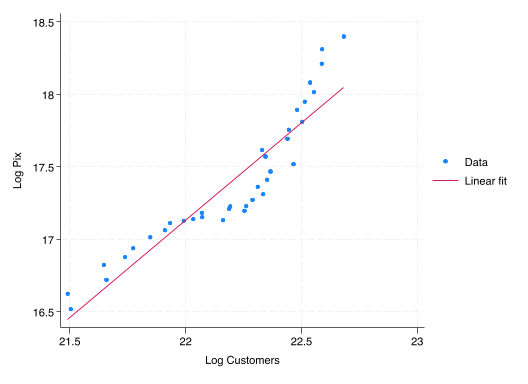

In [155]:
twoway ///
    (scatter l_cust l_pix) (lfit l_cust l_pix), ///
    xtitle("Log Customers") ytitle("Log Pix") ///
    legend(label(1 "Data") label(2 "Linear fit"))

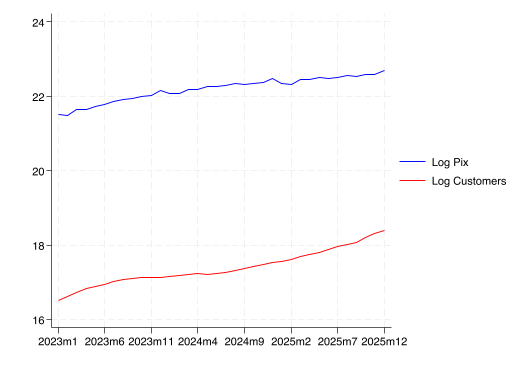

In [156]:
twoway ///
    (line l_pix mdate, sort lcolor(blue)) ///
    (line l_cust mdate, sort lcolor(red)), ///
    legend(order(1 "Log Pix" 2 "Log Customers")) ///
	xtitle(" ") ytitle(" ") ///
    xlabel(`=tm(2023m1)'(5)`=tm(2025m12)', format(%tm))

### Part 2. Baseline Regression Analysis

- We compute heteroskedasticity- and autocorrelation-consistent (HAC) standard errors to account for potential conditional heteroskedasticity and serial correlation in the regression residuals. <br>

- Specifically, we use the Newey–West estimator. And we select the truncation parameter p following a standard data-dependent rule-of-thumb, setting $p = n^{1/4}$, where n denotes the sample size.

In [157]:
newey l_pix l_cust l.selic l.ibc_br l.ipca l.fx l_other, lag(3)


Regression with Newey–West standard errors      Number of obs     =         35
Maximum lag = 3                                 F(  6,        28) =     134.30
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      l_cust |   .7157078   .0517084    13.84   0.000     .6097879    .8216277
             |
       selic |
         L1. |  -.0803901   .0079639   -10.09   0.000    -.0967034   -.0640767
             |
      ibc_br |
         L1. |   .0047782   .0025093     1.90   0.067    -.0003619    .0099183
             |
        ipca |
         L1. |   .0353851   .0185271     1.91   0.066     -.002566    .0733362
             |
          fx |
         L1. |    -.01316   .0312503    -0.42   0.

In [158]:
predict l_pix_hat

(option xb assumed; fitted values)
(1 missing value generated)


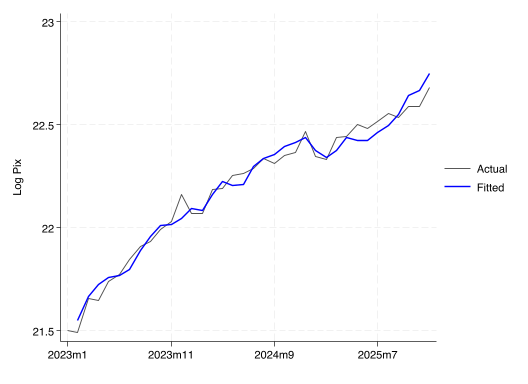

In [159]:
twoway ///
    (line l_pix mdate, sort lcolor(gs5)) ///
    (line l_pix_hat mdate, sort lcolor(blue) lwidth(medthick)), ///
    legend(order(1 "Actual" 2 "Fitted")) ///
    xtitle("") ytitle("Log Pix") ///
    xlabel(`=tm(2023m1)'(10)`=tm(2025m12)', format(%tm))

### Part 3. Interrupted Time Series

In [160]:
clear all
import excel "/Users/xiezuoye/Desktop/Capstone/Brazil_Open_Finance/data.xlsx", sheet("data1") firstrow 

(13 vars, 60 obs)


In [161]:
gen mdate = monthly(month, "MY")
format mdate %tm
tsset mdate


Time variable: mdate, 2021m1 to 2025m12
        Delta: 1 month


In [162]:
gen t = _n
gen post = (mdate >= tm(2021m11))
gen t_post = (mdate - tm(2021m11) + 1) * post
gen l_pix = log(pix)
gen l_other = log(other)

- **Specification:**

$$
\text{l\_pix}_t
=
\alpha
+ \beta_1 t
+ \beta_2 \text{post}_t
+ \beta_3 (t \times \text{post}_t)
+ \gamma_k \text{Controls}_t
$$


In [163]:
newey l_pix t post t_post l.selic l.ibc_br l.ipca l.fx l_other, lag(3)


Regression with Newey–West standard errors      Number of obs     =         59
Maximum lag = 3                                 F(  8,        50) =     300.55
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
       l_pix | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           t |   .1990752   .0208726     9.54   0.000     .1571513    .2409991
        post |   .1389469   .0797436     1.74   0.088    -.0212228    .2991166
      t_post |  -.1646567   .0219529    -7.50   0.000    -.2087504    -.120563
             |
       selic |
         L1. |  -.0109137   .0092945    -1.17   0.246    -.0295822    .0077549
             |
      ibc_br |
         L1. |   .0053529   .0029267     1.83   0.073    -.0005255    .0112313
             |
        ipca |
 

In [164]:
predict l_pix_hat

(option xb assumed; fitted values)
(1 missing value generated)


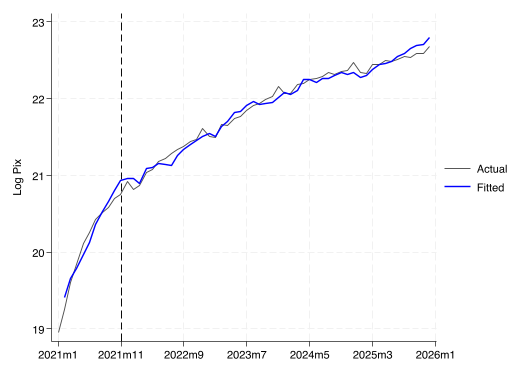

In [165]:
twoway ///
    (line l_pix mdate, sort lcolor(gs5)) ///
    (line l_pix_hat mdate, sort lcolor(blue) lwidth(medthick)), ///
    legend(order(1 "Actual" 2 "Fitted")) ///
    xtitle("") ytitle("Log Pix") ///
    xlabel(`=tm(2021m1)'(10)`=tm(2025m12)', format(%tm)) ///
    xline(`=tm(2021m11)', lpattern(dash))

- **Interpretations:** <br>

    - The results from the interrupted time series (ITS) regression with Newey–West standard errors (lag = 3) indicate a clear structural change in the growth dynamics of Pix following the formal implementation of [Open Finance in November 2021](https://www.bcb.gov.br/en/financialstability/open_finance). We select November 2021 as the official start date of Open Finance because this marks the end of Phase 3, which is when services were formally launched.
    
    - Prior to November 2021, Pix exhibited a strong and statistically significant upward trend. The coefficient of the time variable `t` (0.199, p < 0.001) implies that on average, during the pre-policy period, Pix has a monthly growth rate of roughly 22.02%. <br>

    - The coefficient of the `post` dummy is positive and statistically significant at 10% level (0.139, p = 0.088), suggesting that the implementation of Open Finance generated an immediate level shift in Pix transactions. In other words, there is a discrete jump in Pix activity at the moment of policy implementation, however, the magnitude of this jump is relatively small. <br>

    - However, the interaction term capturing the post-intervention trend change `t_post` is negative and highly significant (-0.165, p < 0.001). This implies a substantial reduction in the slope of the time trend after November 2021. Combining the pre-policy trend with the post-policy adjustment yields a post-policy trend of approximately 3.46% monthly growth rate. Thus, while Pix continued to expand after the implementation of Open Finance, its growth rate declined significantly relative to the initial expansion phase. Several factors may explain this phenomenon: <br>

        - First, the early period of Pix was characterized by rapid diffusion and strong network externalities, typical of digital platform adoption. Once a critical mass of users and merchants had joined the system, marginal growth naturally declined as market penetration increased and the pool of new adopters shrank. <br>

        -  Second, part of the initial expansion reflected a substitution effect, as consumers shifted from cash, bank transfers, and cards to Pix. However, once this substitution process matured, incremental gains became smaller. <br>
        
        - Finally, Open Finance may have contributed to a structural normalization of the payment ecosystem, shifting the system from an explosive adoption phase to a more stable, efficiency-driven expansion path.

### 4. Growth Rate

In [166]:
clear all
import excel "/Users/xiezuoye/Desktop/Capstone/Brazil_Open_Finance/data.xlsx", sheet("data1") firstrow 
gen mdate = monthly(month, "MY")
format mdate %tm
tsset mdate

(13 vars, 60 obs)

Time variable: mdate, 2021m1 to 2025m12
        Delta: 1 month


(2 missing values generated)


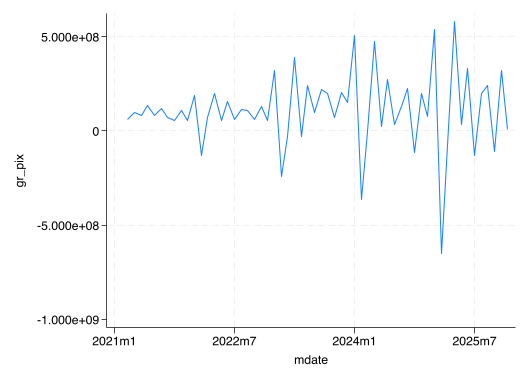

In [167]:
gen gr_pix = dl.pix
tsline gr_pix


Time variable: qdate, 2021q1 to 2025q4
        Delta: 1 quarter
(2 missing values generated)


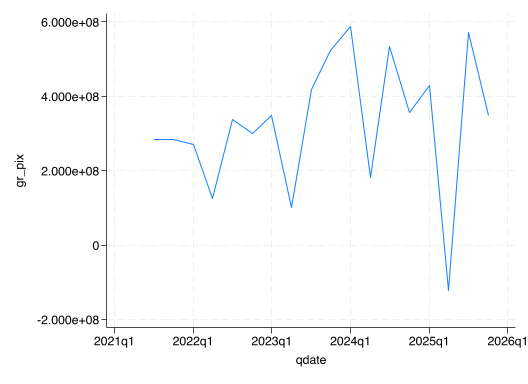

In [168]:
gen qdate = qofd(dofm(mdate))
format qdate %tq
collapse (mean) pix other ibc_br selic ipca fx, by(qdate)
tsset qdate
gen gr_pix = dl.pix
tsline gr_pix